In [1]:
library(Matrix)
library(biomaRt)
library(ggplot2)
library(knitr)
library(scales)
library(viridis)
library(cowplot)

Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal



********************************************************

Note: As of version 1.0.0, cowplot does not change the

  default ggplot2 theme anymore. To recover the previous

  behavior, execute:
  theme_set(theme_cowplot())

********************************************************




In [4]:
#core functions inc. colour palette
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/core_functions.R")


counts = readMM("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/2_calledCells/raw_counts.mtx")
genes = read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/2_calledCells/genes.tsv", stringsAsFactors = F)
barcodes = read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/2_calledCells/barcodes.tsv", stringsAsFactors = F)[,1]

sample = 1:6
stage = rep("8.5", 6)
batch = rep("1", 6)
embryo_pool = 1:6
ID = paste0("SIGA",LETTERS[1:6],"5")

exp_design <- data.frame(sample, stage, batch, embryo_pool, ID)
exp_design

sample,stage,batch,embryo_pool,ID
<int>,<fct>,<fct>,<int>,<fct>
1,8.5,1,1,SIGAA5
2,8.5,1,2,SIGAB5
3,8.5,1,3,SIGAC5
4,8.5,1,4,SIGAD5
5,8.5,1,5,SIGAE5
6,8.5,1,6,SIGAF5


In [5]:
lib.sizes = Matrix::colSums(counts)

split_bc = strsplit(as.character(barcodes), "-", fixed = T)
samples = sapply(split_bc, function(x) x[2])

batch = sapply(samples, function(x){
  if(x %in% 1:26){
    return(1)
  } else{
    return(NA)
  }
})

In [7]:
###==Cell Complexity Thresholding==###

#=Create function to plot change=#

plot_change = function(barcodes, logical_keep){
  split_bc = strsplit(as.character(barcodes), "-", fixed = T)
  samples = sapply(split_bc, function(x) x[2])
  
  pdf = data.frame(Sample = unique(samples),
                   Total = sapply(unique(samples), function(x) sum(samples == x)),
                   Dropped = sapply(unique(samples), function(x) sum(!logical_keep[samples == x])),
                   Retained = sapply(unique(samples), function(x) sum(logical_keep[samples == x])))
  
  p = ggplot(data = pdf) +
          geom_bar(mapping = aes(y = Total, 
                                 x = factor(Sample, levels = unique(samples))), 
                   fill = "darkgrey",
                   stat = "identity") +
          geom_bar(mapping = aes(y = Retained, 
                                 x = factor(Sample, levels = unique(samples))), 
                   fill = "coral",
                   stat = "identity") +
          geom_segment(mapping = aes(y = Total, 
                                     yend = Retained, 
                                     x = factor(Sample, levels = unique(samples)),  
                                     xend = factor(Sample, levels = unique(samples))),
                       arrow = arrow(length = unit(0.1, "inches"))) +
          theme_bw() +
          labs(y = "Number of cells", x= "Sample")
  
  pdf = rbind(pdf, data.frame(Sample = "Total", 
                              Total = length(barcodes), 
                              Dropped = sum(!logical_keep), 
                              Retained = sum(logical_keep)))
    
  return(list(plot = p, df = pdf))
}

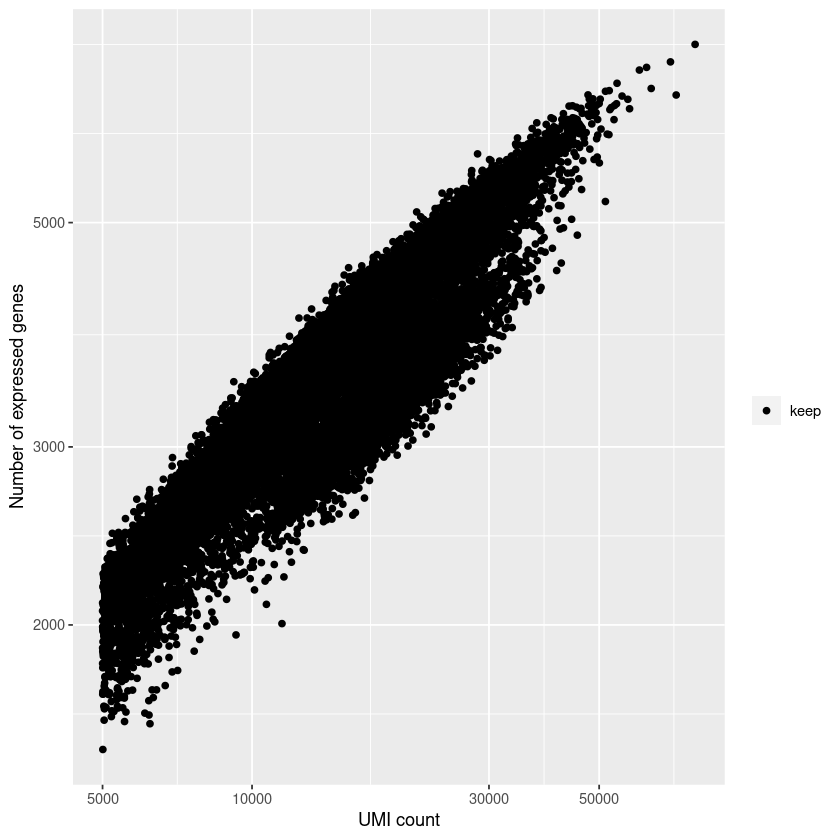

In [17]:
#=Drop cells with low gene counts (<1000)=#

lib.sizes = Matrix::colSums(counts)

ngenes = Matrix::colSums(counts > 0)


qplot(lib.sizes, ngenes, col = ifelse(ngenes < 1000, "drop", "keep")) +
  scale_x_log10() +
  scale_y_log10() +
  labs(x = "UMI count", y = "Number of expressed genes") +
  scale_color_manual(values = c("drop" = "grey50", "keep" = "black"), name = "")

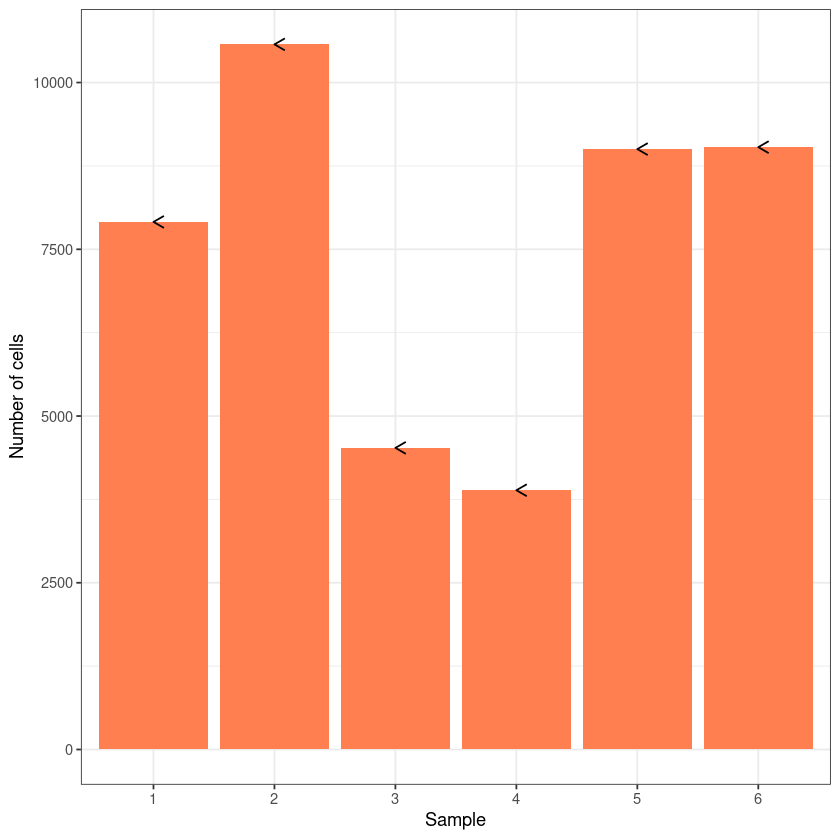

In [18]:
gene_drop = plot_change(barcodes, logical_keep = ngenes > 1000 )

print(gene_drop$plot)

In [19]:
kable(gene_drop$df, caption = "Cells dropped according to low library complexity thresholding.", row.names = FALSE)



|Sample | Total| Dropped| Retained|
|:------|-----:|-------:|--------:|
|1      |  7910|       0|     7910|
|2      | 10572|       0|    10572|
|3      |  4522|       0|     4522|
|4      |  3887|       0|     3887|
|5      |  9002|       0|     9002|
|6      |  9031|       0|     9031|
|Total  | 44924|       0|    44924|

In [ ]:
counts = counts[, ngenes > 1000]
barcodes = barcodes[ngenes > 1000]
ngenes = ngenes[ngenes > 1000]

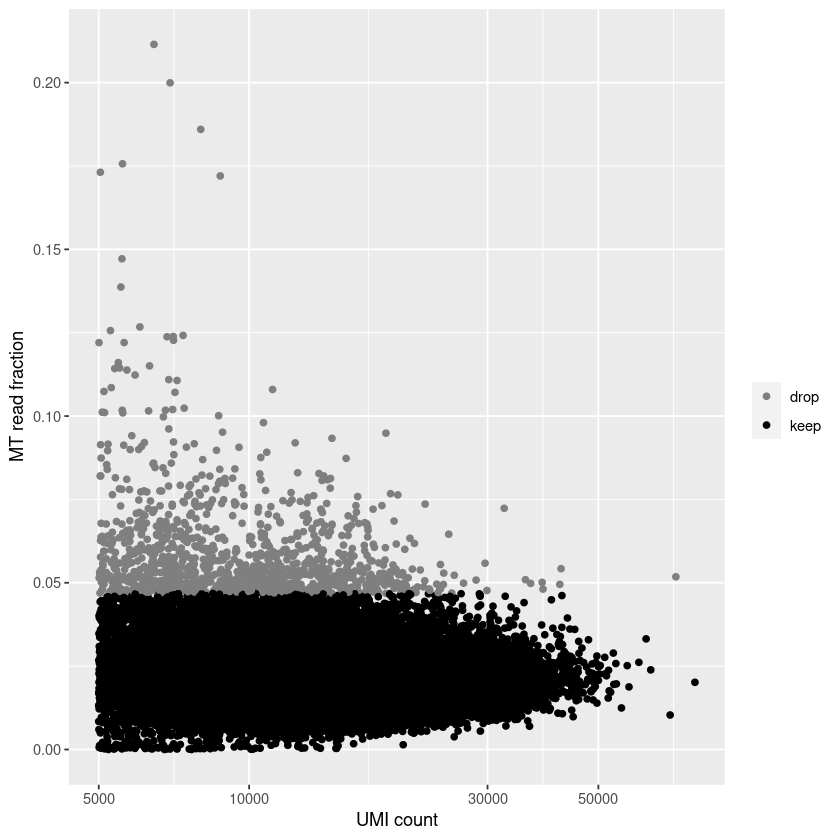

In [23]:
##==Filter cells based on high MT fraction (stressed, apoptotic cells)==##

lib.sizes = colSums(counts)

mouse_ensembl = useMart("ensembl")
mouse_ensembl = useDataset("mmusculus_gene_ensembl", mart = mouse_ensembl)

gene_map = getBM(attributes=c("ensembl_gene_id", "chromosome_name"), values = genes, mart = mouse_ensembl)
mt.counts = counts[which(genes[,1] %in% gene_map$ensembl_gene_id[gene_map$chromosome_name=="MT"]),]
mt.fraction = colSums(mt.counts)/lib.sizes

#fit median-centered, MAD-variance normal 
#crass 5%+
# mt.lim = qnorm(0.95, mean = median(mt.fraction), sd = mad(mt.fraction))
#fdr-corrected outliers
#technically this should be a pt, but the df. is astronomically high so this is essentially the same
mt.p = pnorm(mt.fraction, mean = median(mt.fraction), sd = mad(mt.fraction), lower.tail = FALSE)
mt.lim = min(mt.fraction[which(p.adjust(mt.p, method = "fdr") < 0.05)])

qplot(lib.sizes, mt.fraction, col = ifelse(mt.fraction>mt.lim, "drop", "keep")) +
  scale_x_log10() +
  labs(x = "UMI count", y = "MT read fraction") +
  scale_color_manual(values = c("drop" = "grey50", "keep" = "black"), name = "")

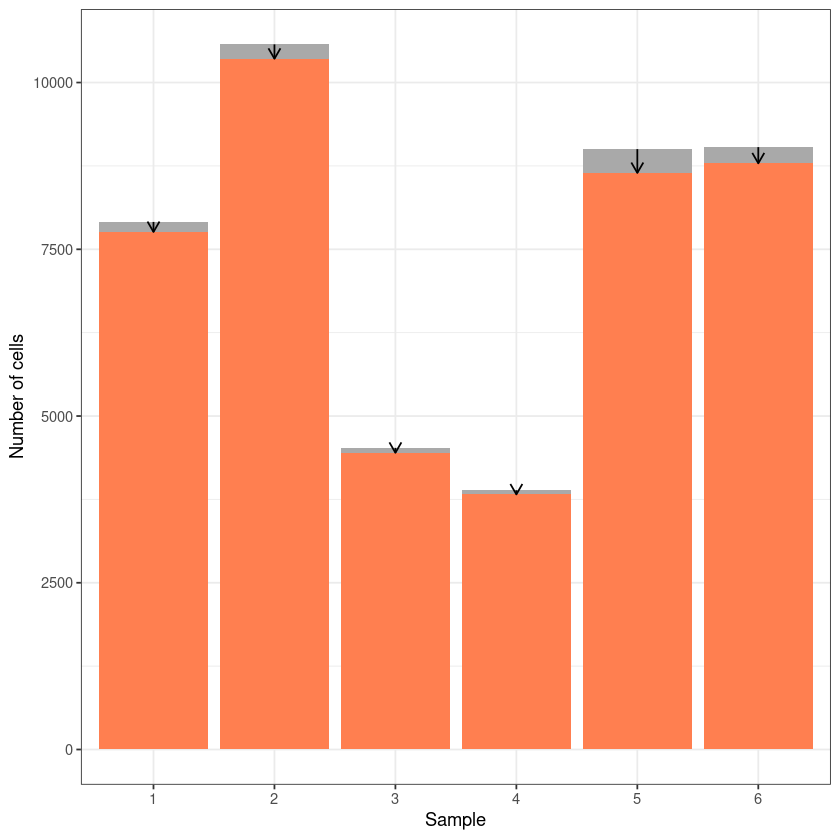

In [24]:
mt_drop = plot_change(barcodes, logical_keep = mt.fraction<mt.lim )

print(mt_drop$plot)

In [25]:
kable(mt_drop$df, caption = "Cells dropped according to mitochondrial fraction threshold", row.names = FALSE)



|Sample | Total| Dropped| Retained|
|:------|-----:|-------:|--------:|
|1      |  7910|     150|     7760|
|2      | 10572|     215|    10357|
|3      |  4522|      73|     4449|
|4      |  3887|      62|     3825|
|5      |  9002|     357|     8645|
|6      |  9031|     242|     8789|
|Total  | 44924|    1099|    43825|

In [26]:
counts = counts[, mt.fraction < mt.lim]
barcodes = barcodes[mt.fraction < mt.lim]
mt.fraction = mt.fraction[mt.fraction < mt.lim]

# Number of detected genes

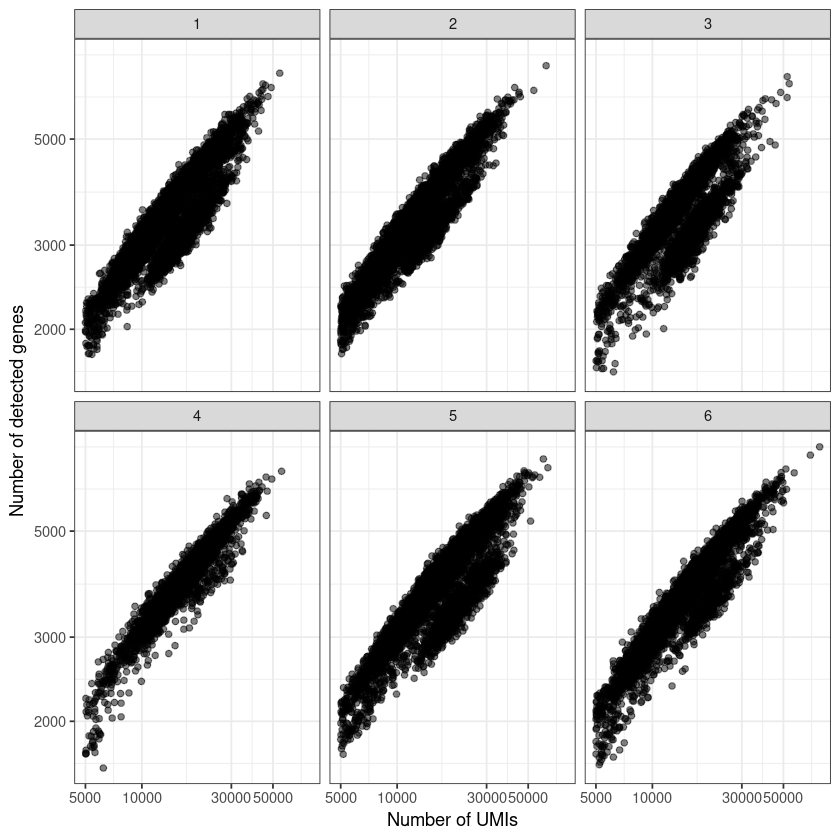

In [27]:
lib.sizes = colSums(counts)
n.genes = colSums(counts>0)

split_bc = strsplit(as.character(barcodes), "-", fixed = T)
bcs = sapply(split_bc, function(x) x[1])
samples = sapply(split_bc, function(x) x[2])

plot_df = data.frame(lib = lib.sizes, genes = n.genes, sample = samples)
plot_df = plot_df[sample(nrow(plot_df), nrow(plot_df), replace = FALSE),]

p = ggplot(plot_df, aes(x = lib, y = genes)) +
  geom_point(alpha = 0.5) +
  scale_colour_Publication() +
  scale_y_log10() +
  scale_x_log10() +
  theme_bw() +
  facet_wrap(~factor(sample, levels = unique(sample)[order(nchar(unique(as.character(sample))), unique(sample))]), ncol = 3) +
  labs(x = "Number of UMIs", y = "Number of detected genes")

suppressWarnings(plot(p))

# Inter-sample Comparisons

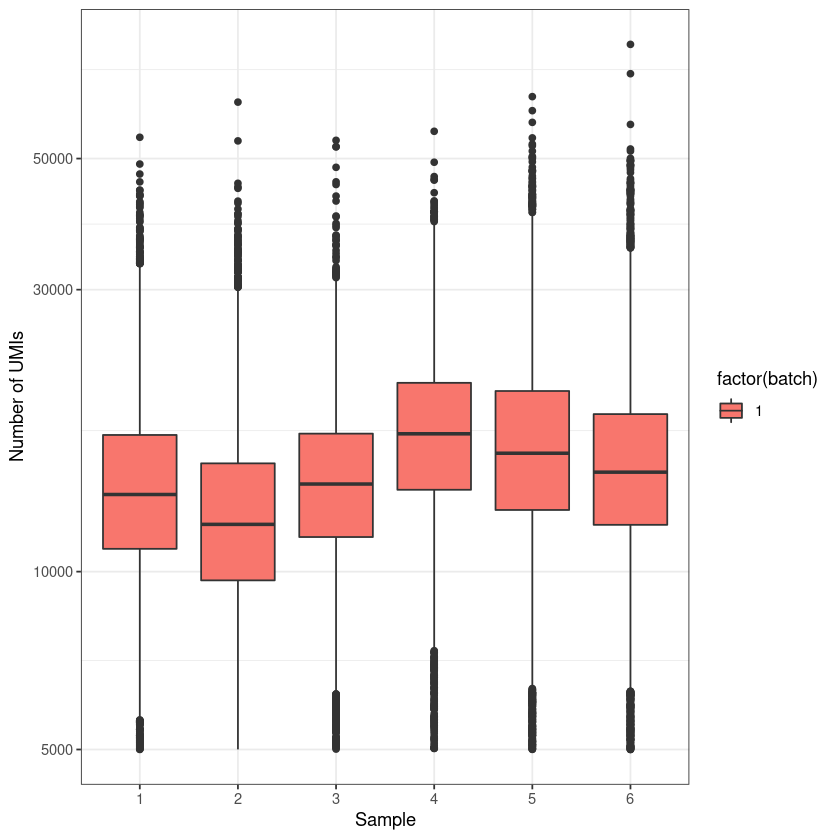

In [30]:
batch = ifelse(as.numeric(samples) <= 6,
               1,
               2)

p = ggplot(data.frame(lib = lib.sizes, sample = samples), aes (x = factor(sample, levels = unique(sample)), 
                                                           y = lib.sizes, fill = factor(batch))) +
  geom_boxplot() +
  theme_bw() +
  scale_y_log10() +
  labs(x = "Sample", y = "Number of UMIs")+
  scale_color_brewer(palette = "Set1", name = "Sequencing\nbatch")

suppressWarnings(plot(p))

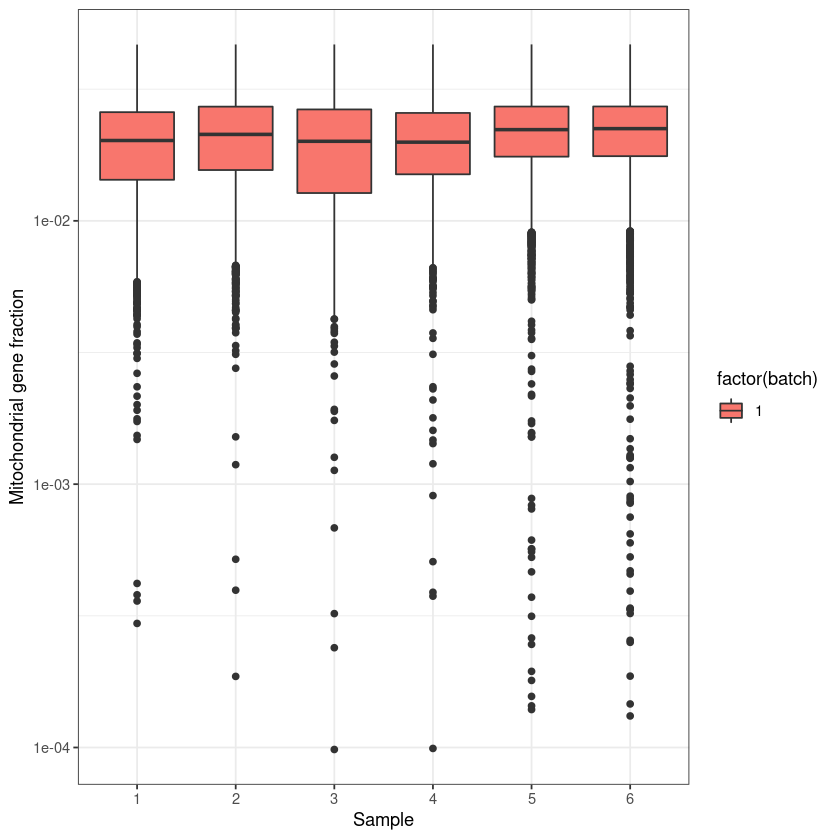

In [31]:
p = ggplot(data.frame(mt = mt.fraction, sample = samples), aes (x = factor(sample, levels = unique(sample)), 
                                                           y = mt, fill = factor(batch))) +
  geom_boxplot() +
  theme_bw() +
  scale_y_log10() +
  labs(x = "Sample", y = "Mitochondrial gene fraction") +
  scale_color_brewer(palette = "Set1", name = "Sequencing\nbatch")

suppressWarnings(plot(p))

In [41]:
stage_match = read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/3_QC/sample_stage.csv", sep = ",", header = TRUE)


In [42]:
split_bc = strsplit(as.character(barcodes), "-", fixed = T)
bcs = sapply(split_bc, function(x) x[1])
samples = sapply(split_bc, function(x) x[2])



meta = data.frame(cell = paste0("cell_", 1:ncol(counts)),
                  barcode = bcs,
                  sample = as.numeric(samples),
                  stage = stage_match$stage[match(samples, stage_match$sample)],
                  batch = stage_match$batch[match(samples, stage_match$sample)])

In [40]:
stage_match

sample,stage,batch,embryo_pool,ID
<int>,<dbl>,<int>,<int>,<fct>
1,8.5,1,1,SIGAA5
2,8.5,1,2,SIGAA6
3,8.5,1,3,SIGAA7
4,8.5,1,4,SIGAA8
5,8.5,1,5,SIGAA9
6,8.5,1,6,SIGAA10


In [43]:
tab = as.matrix(table(meta$sample, meta$stage))

new_rownames = c("Total", rownames(tab))
tab = rbind(sapply(colnames(tab), function(x) sum(meta$stage == x)),
            tab)
rownames(tab) = new_rownames

pt = kable(tab, caption = "Number of cells retained for analysis")
pt



|      |   8.5|
|:-----|-----:|
|Total | 43825|
|1     |  7760|
|2     | 10357|
|3     |  4449|
|4     |  3825|
|5     |  8645|
|6     |  8789|

In [46]:
wd <- "/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/3_QC/"

null_holder = writeMM(counts, file = paste0(wd,"matrix.mtx"))
saveRDS(as(counts, "dgCMatrix"), file = paste0(wd,"raw_counts.rds"))
write.table(barcodes, file = paste0(wd,"barcodes.tsv"), row.names = F, col.names = F, quote = F, sep = "\t")
write.table(meta, file = paste0(wd,"meta.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

In [58]:
summary(lib.sizes)
summary(ngenes)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   5000   11210   14169   15245   18051   78020 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1506    3102    3515    3576    3992    7503 

In [62]:
UMI_avg = c(median(lib.sizes[meta$sample==1]),
            median(lib.sizes[meta$sample==2]),
            median(lib.sizes[meta$sample==3]),
            median(lib.sizes[meta$sample==4]),
            median(lib.sizes[meta$sample==5]),
            median(lib.sizes[meta$sample==6]))

UMI_avg

[1] 13504 12021 14068 17109 15860 14733

In [57]:
median(ngenes[meta$sample==1])
median(ngenes[meta$sample==2])
median(ngenes[meta$sample==3])
median(ngenes[meta$sample==4])
median(ngenes[meta$sample==5])
median(ngenes[meta$sample==6])

[1] 3381

[1] 3280

[1] 3420

[1] 3901

[1] 3717

[1] 3609

In [59]:
seq_sat <- c(16.9, 16.5, 16.5, 19.1, 19.2,18.7)

In [61]:
cor(seq_sat, UMI_avg)

[1] 0.8649601